In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Diabetespred.csv')

print("Dataset loaded successfully")
print(f"Shape: {df.shape}\n{df.head}")


Dataset loaded successfully
Shape: (499, 9)
<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
494            3       80              0              0        0   0.0   
495            6      166             74              0        0  26.6   
496            5      110             68              0        0  26.0   
497            2       81             72             15       76  30.1   
498            7      195             70             33      145  25.1   

     DiabetesPedigreeFunction  Age  O

In [ ]:
# Prepare features and target
X = df.drop('Outcome', axis=1)  
y = df['Outcome']               

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# Build KNN Classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

print("KNN Classifier (k=5) trained successfully!")

KNN Classifier (k=5) trained successfully!


In [21]:
# Calculate quantitative parameters
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


print("KNN CLASSIFIER RESULTS (k=5)")

print("\n PERFORMANCE METRICS:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

print("=" * 60)

KNN CLASSIFIER RESULTS (k=5)

 PERFORMANCE METRICS:
  Accuracy:  0.7500 (75.00%)
  Precision: 0.6774
  Recall:    0.5833
  F1-Score:  0.6269

 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81        64
    Diabetes       0.68      0.58      0.63        36

    accuracy                           0.75       100
   macro avg       0.73      0.71      0.72       100
weighted avg       0.74      0.75      0.75       100



<Axes: >

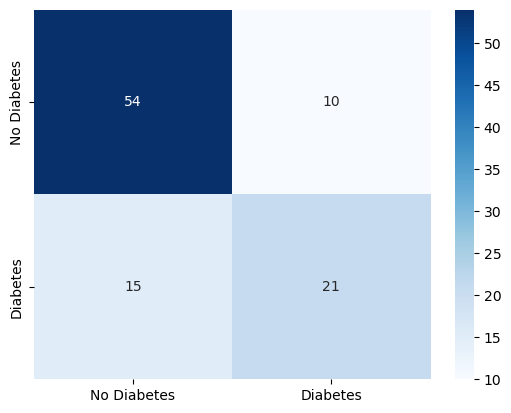

In [ ]:


sns.heatmap(cm, annot=True, cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes']
            )

